In [1]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, GRU, LSTM, Dense, Dropout, 
                                     Bidirectional, Conv1D, GlobalMaxPooling1D, 
                                     Flatten, Concatenate,MultiHeadAttention, LayerNormalization)
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics.pairwise import cosine_similarity
# Load and clean data
df = pd.read_csv("../all_data_cleaned.csv")
df.dropna(subset=["title", "supercategory_cleaned", "Bow", "weighted_rating_class_2"], inplace=True)
df = df.sample(n=100000, random_state=6).reset_index(drop=True)

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# Process labels
def list_to_str(x):
    if isinstance(x, str):
        try:
            lst = ast.literal_eval(x)
            return ' '.join(sorted(set(lst))) if isinstance(lst, list) else str(lst)
        except:
            return str(x)
    return str(x)

df["super_str"] = df["supercategory_cleaned"].apply(list_to_str)

# Label encoding
le_label = LabelEncoder()
df["y_label"] = le_label.fit_transform(df["super_str"])

In [3]:
# Clean text
def clean_text(text):
    if isinstance(text, str):
        words = text.lower().strip().split()
        return ' '.join(sorted(set(words)))
    return ""

df["clean_text"] = df["Bow"].apply(clean_text)

# Tokenization
tokenizer = Tokenizer(num_words=3000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])
seq = tokenizer.texts_to_sequences(df["clean_text"])
padded_seq = pad_sequences(seq, maxlen=40, padding="post")

# Numeric data
scaler = MinMaxScaler()
numeric_data = scaler.fit_transform(df[["weighted_rating_class_2"]].astype(float))

# Prepare targets
y = to_categorical(df["y_label"])
num_classes = y.shape[1]

# Remove classes with only one sample
class_counts = pd.Series(np.argmax(y, axis=1)).value_counts()
single_sample_classes = class_counts[class_counts == 1].index
mask = ~np.isin(np.argmax(y, axis=1), single_sample_classes)

X_text = padded_seq[mask]
X_num = numeric_data[mask]
y = y[mask]
num_classes = y.shape[1]

# Train-test split
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text, X_num, y, test_size=0.3, random_state=42, stratify=np.argmax(y, axis=1)
)

In [4]:
def build_model(model_type="bigru"):
    input_text = Input(shape=(40,))
    x = Embedding(input_dim=3001, output_dim=300)(input_text)
    
    if model_type == "gru":
        x = GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)(x)
        x = GRU(128, dropout=0.3, recurrent_dropout=0.3)(x)
    elif model_type == "lstm":
        x = LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)(x)
        x = LSTM(128, dropout=0.3, recurrent_dropout=0.3)(x)
    elif model_type == "bigru":
        x = Bidirectional(GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(x)
        x = GlobalMaxPooling1D()(x)
    elif model_type == "bilstm":
        x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(x)
        x = GlobalMaxPooling1D()(x)
    elif model_type == "cnn":
        x = Conv1D(128, 5, activation='relu')(x)
        x = Conv1D(128, 3, activation='relu')(x)
        x = GlobalMaxPooling1D()(x)
    elif model_type == "attention":
        x = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
        x = LayerNormalization()(x)
        x = GlobalMaxPooling1D()(x)
    else:
        raise ValueError("Invalid model type. Choose from: gru, lstm, bigru, bilstm, cnn, attention, capsule, tcn")

    input_num = Input(shape=(1,))
    y = Dense(64, activation='relu')(input_num)

    z = Concatenate()([x, y])
    z = Dropout(0.5)(z)
    z = Dense(256, activation='relu')(z)
    output = Dense(num_classes, activation='softmax')(z)

    model = Model(inputs=[input_text, input_num], outputs=output)
    model.compile(optimizer=Adam(0.00025), 
                 loss="categorical_crossentropy", 
                 metrics=["accuracy"])
    return model

In [5]:
def train(model_type="bigru"):
    model = build_model(model_type)
    
    history = model.fit(
        [X_train_text, X_train_num], y_train,
        validation_data=([X_test_text, X_test_num], y_test),
        epochs=5, 
        batch_size=32,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
    )

    model.save(f"{model_type}_supercategory_model.keras")
    joblib.dump(tokenizer, "tokenizer.pkl")
    joblib.dump(le_label, "le_label.pkl")
    joblib.dump(scaler, "scaler.pkl")

    # Plot training history
    plt.figure(figsize=(12, 5))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Test Loss')  # Validation -> Test
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')  # Validation -> Test
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    y_pred = np.argmax(model.predict([X_test_text, X_test_num], verbose=0), axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    print(classification_report(y_true, y_pred, 
                              target_names=le_label.classes_,
                              labels=np.arange(len(le_label.classes_)),
                              zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, average="weighted"))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    
    return history

In [6]:
def get_recommendations(user_text, rating_class, model_type="bigru", top_k=5):
    model = tf.keras.models.load_model(f"{model_type}_supercategory_model.keras")
    tokenizer = joblib.load("tokenizer.pkl")
    le_label = joblib.load("le_label.pkl")
    scaler = joblib.load("scaler.pkl")

    clean_input = ' '.join(sorted(set(user_text.lower().strip().split())))
    seq = tokenizer.texts_to_sequences([clean_input])
    padded = pad_sequences(seq, maxlen=40, padding="post")
    numeric_input = scaler.transform(np.array([[rating_class]]))

    pred_idx = np.argmax(model.predict([padded, numeric_input], verbose=0))
    pred_super = le_label.inverse_transform([pred_idx])[0]
    
    super_df = df[df["super_str"] == pred_super].copy()
    
    if len(super_df) == 0:
        return pred_super, None

    embed_model = Model(inputs=model.inputs, outputs=model.layers[-3].output)
    
    user_embedding = embed_model.predict([padded, numeric_input], verbose=0)
    
    seqs = tokenizer.texts_to_sequences(super_df["clean_text"])
    padded_seqs = pad_sequences(seqs, maxlen=40, padding="post")
    numeric_super = scaler.transform(super_df[["weighted_rating_class_2"]].values)
    prod_embeddings = embed_model.predict([padded_seqs, numeric_super], verbose=0)
    
    similarities = cosine_similarity(user_embedding, prod_embeddings)[0]
    super_df["similarity"] = similarities
    
    top_products = super_df.sort_values(by="similarity", ascending=False).head(top_k)
    
    return pred_super, top_products[["title", "price", "rating", "product_url", "similarity"]]

Epoch 1/5
2188/2188 [==============================] - 13s 5ms/step - loss: 0.9409 - accuracy: 0.8118 - val_loss: 0.0770 - val_accuracy: 0.9815
Epoch 2/5
2188/2188 [==============================] - 11s 5ms/step - loss: 0.0639 - accuracy: 0.9857 - val_loss: 0.0405 - val_accuracy: 0.9893
Epoch 3/5
2188/2188 [==============================] - 12s 6ms/step - loss: 0.0365 - accuracy: 0.9907 - val_loss: 0.0400 - val_accuracy: 0.9898
Epoch 4/5
2188/2188 [==============================] - 13s 6ms/step - loss: 0.0251 - accuracy: 0.9932 - val_loss: 0.0385 - val_accuracy: 0.9910
Epoch 5/5
2188/2188 [==============================] - 14s 6ms/step - loss: 0.0200 - accuracy: 0.9940 - val_loss: 0.0403 - val_accuracy: 0.9902


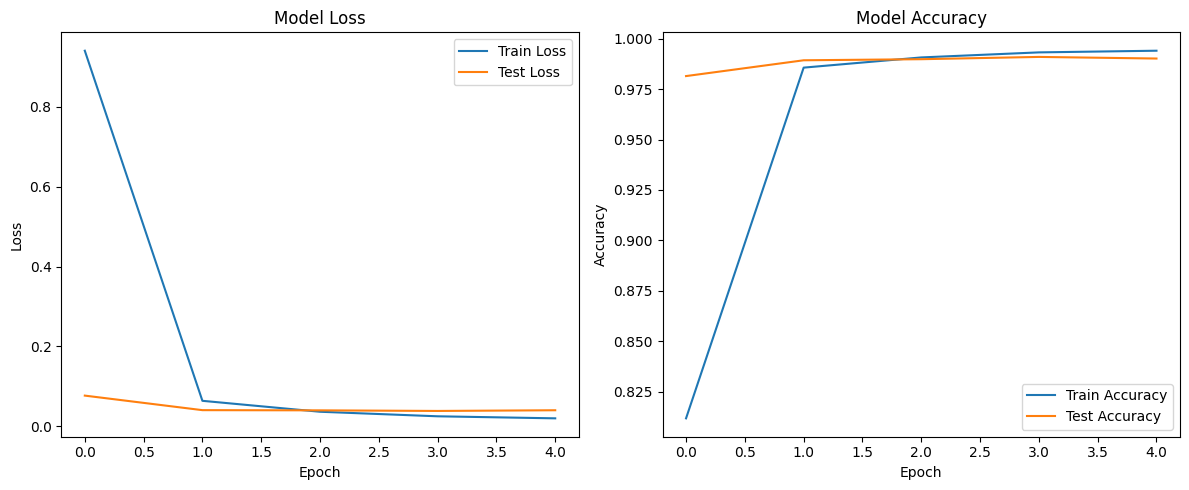

                                 precision    recall  f1-score   support

                         abajur       0.88      0.78      0.82        18
            acma alt bebek bezi       0.00      0.00      0.00         0
                       aksesuar       1.00      0.99      0.99       589
         aksesuar arabasi bebek       0.89      0.94      0.92        18
            aksesuar giyim spor       1.00      1.00      1.00        45
                   aksesuar oto       1.00      0.99      1.00      1506
        aksesuari arabasi bebek       1.00      1.00      1.00        15
          aksesuari koltugu oto       1.00      0.97      0.98        29
      aksesuari mama sandalyesi       1.00      0.95      0.98        22
                    aksesuarlar       0.99      1.00      1.00       653
           aksesuarlari aksiyon       0.87      0.93      0.90        14
        aksesuarlari aydinlatma       0.94      0.94      0.94        18
             aksesuarlari banyo       1.00      0.

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: motosiklet
Top recommended products:
                                                                                                                                                                                                title   price  rating                                                                                                                                                                                                          product_url  similarity
                                                                                                          ['renault', 'ozel', 'uyumlu', 'aksesuar', 'oto', 'cam', 'oto', 'ozel', 'sticker', 'karbon']  169.00     0.0                                                                                  https://www.hepsiburada.com/renault-megane1-icin-ozel-yeni-uyumlu-aksesuar-oto-on-cam-oto-ozel-yeni-sticker-karbon-pm-HBC00008T3DIX    0.730745
                                                            

In [7]:
selected_model_type = "attention"
train(selected_model_type)

sample_input = "Araç torpido üstü aksesuarı"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

In [8]:
sample_input = "Bebek"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: bebek
Top recommended products:
                                            title   price  rating                                                                                    product_url  similarity
                         ['karadeniz', 'baskili']  159.99     0.0                           https://www.hepsiburada.com/limon-karadeniz-baskili-p-HBCV000005Y2GO    0.993468
                   ['askili', 'ananasli', 'body']  103.67     0.0                           https://www.hepsiburada.com/ip-askili-ananasli-body-p-HBCV000098RRBS    0.993365
['puanli', 'bandanali', 'body', 'yesil', 'yesil']  378.99     0.0 https://www.hepsiburada.com/candar-3-6-9-ay-puanli-bandanali-body-yesil-yesil-p-HBCV00006T76G2    0.993169
                  ['lisansli', 'uzunkol', 'body']  500.00     4.5           https://www.hepsiburada.com/batman-lisansli-2-li-uzunkol-body-18267-pm-HBC00000MKHLM    0.992915
     ['patikli', 'eldivenli', 'kozmonot', 'mavi'] 1350.00     0.0             

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [9]:
sample_input = "Oto aksesuar"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: aksesuar oto
Top recommended products:
                                  title   price  rating                                                                                       product_url  similarity
                                ['rag']   980.0     5.0                                  https://www.hepsiburada.com/auto-finesse-rag-top-pm-HB00000AHQU7    0.999760
            ['tolsen', 'cam', 'kesici']   296.0     5.0                https://www.hepsiburada.com/tolsen-41029-tolsen-4-10mm-cam-kesici-pm-HBC00006DH7LR    0.997094
          ['fircasiz', 'oto', 'kopugu']   650.0     0.0                         https://www.hepsiburada.com/ozon-fircasiz-oto-kopugu-5kg-pm-HBC00007CS4NL    0.995641
['fircasiz', 'oto', 'yikama', 'kopugu']  1200.0     0.0               https://www.hepsiburada.com/sensu-fircasiz-oto-yikama-kopugu-20-lt-pm-HBC000030JGC9    0.995641
         ['napoli', 'black', 'diamond'] 14500.0     0.0 https://www.hepsiburada.com/4x108x15-6-5-65-1-et20

In [10]:
sample_input = "Iphone cep telefonu aksesuarı telefon tutacağı"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: aksesuarlari cep telefonu
Top recommended products:
                                                                                                                                                                                     title  price  rating                                                                                                                                                                              product_url  similarity
             ['huawei', 'mate', 'lite', 'kilif', 'rugged', 'armor', 'darbe', 'emici', 'omurlu', 'dayanikli', 'parmak', 'i̇zi', 'yapmaz', 'karbon', 'tasarim', 'negro', 'silikon', 'kapak'] 148.90     4.7        https://www.hepsiburada.com/fibaks-huawei-mate-20-lite-kilif-rugged-armor-darbe-emici-uzun-omurlu-dayanikli-parmak-izi-yapmaz-karbon-tasarim-negro-silikon-kapak-pm-HBC00007UIUR9    0.939635
                                                                                                                    ['xiaomi'

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [11]:
sample_input = "Bilgisayar"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: bilgisayar parcalari yedek
Top recommended products:
                                           title   price  rating                                                                                                product_url  similarity
       ['asus', 'mentese', 'seti', 'sag', 'sol']  783.99     0.0                               https://www.hepsiburada.com/asus-a52jc-mentese-seti-sag-sol-pm-HBC00006V0XQJ    0.809493
       ['asus', 'mentese', 'seti', 'sag', 'sol']  602.32     0.0                        https://www.hepsiburada.com/modanom-asus-f3jm-mentese-seti-sag-sol-pm-HBC00006V12ZT    0.809493
       ['asus', 'mentese', 'seti', 'sag', 'sol']  729.56     0.0                               https://www.hepsiburada.com/asus-x82cr-mentese-seti-sag-sol-pm-HBC00006V0Y3R    0.809493
       ['asus', 'mentese', 'seti', 'sag', 'sol']  602.32     0.0                                https://www.hepsiburada.com/asus-f3jc-mentese-seti-sag-sol-pm-HBC00006V1BP1    0.809493
['

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [12]:
sample_input = "Erkek alt giyim pantolon"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: giyim
Top recommended products:
                                                               title   price  rating                                                                                                      product_url  similarity
                                ['erkek', 'kot', 'pantolon', 'mavi'] 1061.50     5.0                                 https://www.hepsiburada.com/balins-erkek-kot-pantolon-acik-mavi-p-HBCV000004XOCK    0.995146
['erkek', 'marcus', 'golgeli', 'mavi', 'sporty', 'jean', 'pantolon'] 1599.99     4.8 https://www.hepsiburada.com/mavi-erkek-marcus-golgeli-koyu-mavi-sporty-jean-pantolon-0035182162-p-HBCV00004039KQ    0.990766
                                               ['erkek', 'pantolon'] 1599.60     0.0                                                      https://www.hepsiburada.com/erkek-pantolon-p-HBCV00008L9JJS    0.990724
                    ['erkek', 'duble', 'paca', 'kompak', 'pantolon']  600.00     0.0                   

In [13]:
sample_input = "Kadın üst giyim t-shirt"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: giyim
Top recommended products:
                                                      title     price  rating                                                                                     product_url  similarity
                                          ['fok', 'bolero']    649.00     3.0                                    https://www.hepsiburada.com/navy-fok-bolero-p-HBCV00003FH39R    0.997481
                                          ['fok', 'bolero']    649.00     3.0                                    https://www.hepsiburada.com/navy-fok-bolero-p-HBCV00003FH2ZR    0.997481
['prestijboncuk', 'trendy', 'tarlatan', 'korsed', 'series']    434.54     5.0 https://www.hepsiburada.com/prestijboncuk-trendy-tarlatan-korsed-series-ks-427-pm-HBC00002U8UHN    0.996777
                                               ['gelinlik'] 145000.00     0.0                                     https://www.hepsiburada.com/vakko-gelinlik-pm-HBC00005A7P3L    0.996745
['prestijbonc

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [14]:
sample_input = "Kitap"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: kitap
Top recommended products:
                                  title  price  rating                                                                       product_url  similarity
                          ['astronomi'] 372.90     5.0                             https://www.hepsiburada.com/astronomi-pm-HB00000O8B41    0.999696
                              ['karar'] 149.00     4.7              https://www.hepsiburada.com/2023-karar-zeynep-turan-pm-HBC000038LR8Z    0.999696
 ['koc', 'citir', 'citir', 'astroloji'] 110.00     4.3             https://www.hepsiburada.com/koc-citir-citir-astroloji-pm-HB0000011MVF    0.999384
             ['insanlari', 'seviyorum']  80.22     5.0 https://www.hepsiburada.com/neden-hep-yanlis-insanlari-seviyorum-pm-HBC00003804AA    0.999384
['boga', 'citir', 'citir', 'astroloji'] 110.00     3.5            https://www.hepsiburada.com/boga-citir-citir-astroloji-pm-HB0000011MPD    0.999384


In [15]:
sample_input = "samsung tablet android 128gb"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: tablet
Top recommended products:
                                                                                  title    price  rating                                                                                                                                      product_url  similarity
        ['hiking', 'akilli', 'tablet', 'ekran', 'android', 'wifi', 'kilif', 'hediyeli']  4500.00     0.0                          https://www.hepsiburada.com/hiking-p15-akilli-tablet-10-1-ekran-4-64gb-android-14-wi-fi-kilif-hediyeli-pm-HBC000082VK7Y    0.930617
['galaxy', 'tab', 'ultra', 'hatli', 'tablet', 'gri', 'samsung', 'turkiye', 'garantili'] 47039.02     0.0 https://www.hepsiburada.com/samsung-galaxy-tab-s10-ultra-5g-sm-x926b-12gb-512gb-14-6-hatli-tablet-gri-samsung-turkiye-garantili-pm-HBC00008IJ1LS    0.909386
            ['ipad', 'pro', 'wifi', 'cellular', 'nanotexture', 'cam', 'uzay', 'siyahi'] 77999.00     5.0                       https://www.hepsiburada.com/a

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [16]:
sample_input = "Mutfak çay makinesi"
pred_super, results = get_recommendations(
        user_text=sample_input,
        rating_class=1,
        model_type=selected_model_type,
        top_k=5
    )

print("Predicted Supercategory:", pred_super)
if results is not None:
    print("Top recommended products:")
    print(results.to_string(index=False))
else:
    print("No products found in this supercategory")

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Supercategory: mutfak
Top recommended products:
                                                  title  price  rating                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

C:\Users\kurt_\anaconda3\envs\pytorch-transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
